In [14]:
from langgraph.graph import StateGraph, END

# Define a basic state type (customize based on your needs)
class GraphState(dict): pass

# Build the graph
builder = StateGraph(GraphState)

def llm_logic():
    pass
def tools_logic():
    pass
def web_logic():
    pass    
def db_logic(): 
    pass
def summary_logic():    
    pass
def generator_logic():
    pass
def limit_check():
    pass

# Add nodes (functions or logic to be implemented separately)
builder.add_node("LLM", llm_logic)
builder.add_node("Tools", tools_logic)
builder.add_node("Web", web_logic)
builder.add_node("DB", db_logic)
builder.add_node("Summary", summary_logic)
builder.add_node("Generator", generator_logic)

# Define edges
builder.set_entry_point("LLM")

builder.add_edge("LLM", "Generator")     # Direct path to Generator
builder.add_edge("LLM", "Tools")         # Conditional path to Tools

builder.add_edge("Tools", "Web")
builder.add_edge("Tools", "DB")

builder.add_edge("Web", "Summary")
builder.add_edge("DB", "Summary")

builder.add_edge("Summary", "Generator")

builder.add_edge("Generator", END)

# If limit condition applies, assume some conditional logic
builder.add_conditional_edges(
    "LLM",
    limit_check,  # This is the function that determines the path
    {
        "limit_reached": "Generator",
        "use_tools": "Tools"
    }
)

graph = builder.compile()
print(graph)


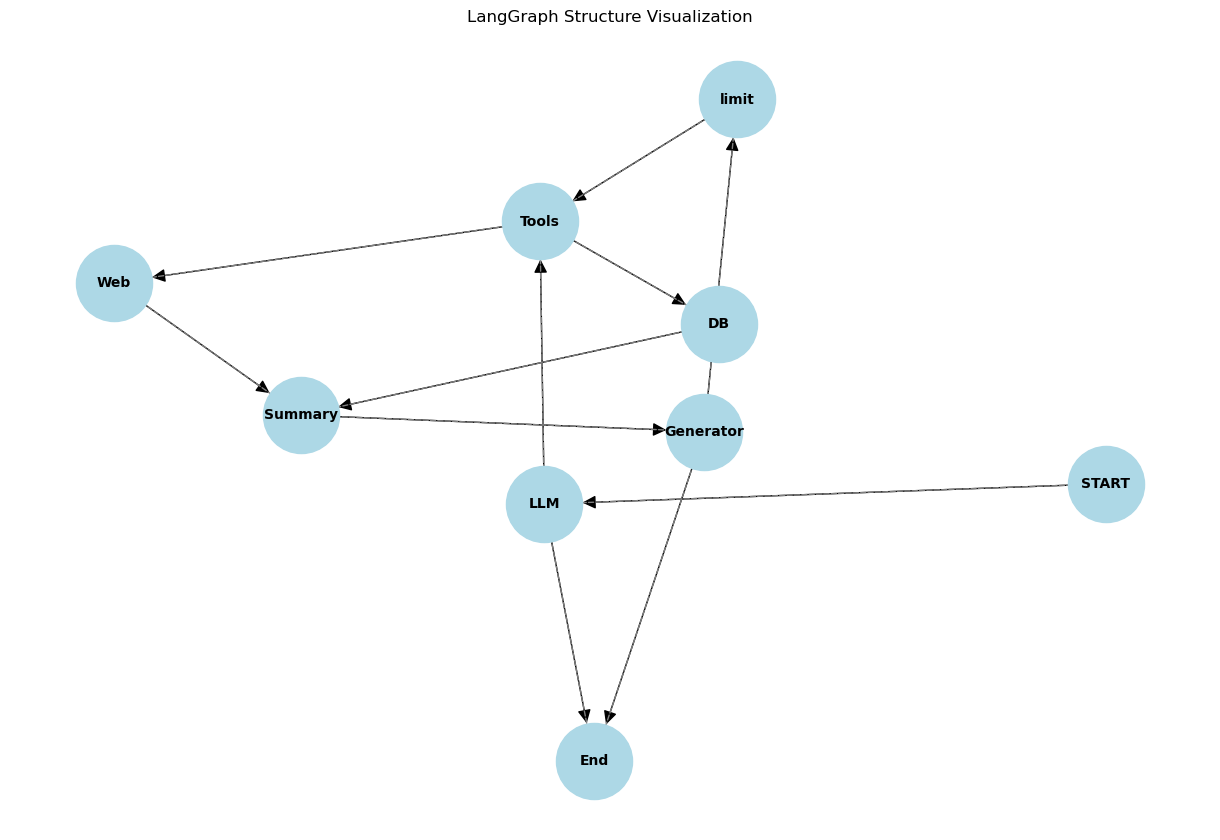

In [22]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()

# Nodes
nodes = ["START", "LLM", "Tools", "Web", "DB", "Summary", "Generator", "End", "limit"]
G.add_nodes_from(nodes)

# Edges
edges = [
    ("START", "LLM"),
    ("LLM", "End"),
    ("LLM", "Tools"),
    ("Tools", "Web"),
    ("Tools", "DB"),
    ("Web", "Summary"),
    ("DB", "Summary"),
    ("Summary", "Generator"),
    ("Generator", "End"),
    ("Generator", "limit"),
    ("limit", "Tools"),
    
]
G.add_edges_from(edges)

# Visualize
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_size=3000, node_color='lightblue', font_size=10, font_weight='bold', arrowsize=20)
nx.draw_networkx_edges(G, pos, style='dashed', edge_color='gray')
plt.title("LangGraph Structure Visualization")
plt.show()
